# Moguls Elegance Score (MES) — 60-Punkte-Modell

Dieses Notebook implementiert den **Moguls Elegance Score** auf Basis von 2D-Pose-Keypoints (YOLOv8 / COCO-17).  
Es operationalisiert die Turn-Kriterien aus Kapitel 6204.1 des FIS Judging Handbook (Turns — 60%).

**Gesamtformel:**
$$\text{MES}_{60} = 10 \cdot R + 10 \cdot S + 10 \cdot M + 10 \cdot Y + 10 \cdot C + 10 \cdot L$$

mit $R, S, M, Y, C, L \in [0, 1]$

| Kürzel | Komponente | FIS-Bezug |
|--------|-----------|----------|
| R | Rhythmus | Rhythmic changes in direction of travel |
| S | Stabilität | Upper body / Breaks in balance |
| M | Smoothness (Jerk) | No skidding / lateral sliding |
| Y | Symmetrie | Movements symmetrical and equal side to side |
| C | Bein-Kompaktheit | Legs should be together |
| L | Line Integrity | Skiing in the fall line |

## 0. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks, savgol_filter
from pathlib import Path
import glob
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. COCO-17 Keypoint Index Reference

Für dieses Modell werden nur folgende Keypoints verwendet:

| Index | Keypoint |
|-------|----------|
| 5 | L-Shoulder |
| 6 | R-Shoulder |
| 11 | L-Hip |
| 12 | R-Hip |
| 13 | L-Knee |
| 14 | R-Knee |
| 15 | L-Ankle |
| 16 | R-Ankle |

In [2]:
# Keypoint-Spaltenpräfixe — passend zu den CSV-Spaltennamen der Pipeline
# Format: '{name}_x', '{name}_y', '{name}_conf'
KP = {
    'L_SHOULDER': 'left_shoulder',
    'R_SHOULDER': 'right_shoulder',
    'L_HIP':      'left_hip',
    'R_HIP':      'right_hip',
    'L_KNEE':     'left_knee',
    'R_KNEE':     'right_knee',
    'L_ANKLE':    'left_ankle',
    'R_ANKLE':    'right_ankle',
}
print('Keypoint-Spalten:', KP)

Keypoint-Spalten: {'L_SHOULDER': 'left_shoulder', 'R_SHOULDER': 'right_shoulder', 'L_HIP': 'left_hip', 'R_HIP': 'right_hip', 'L_KNEE': 'left_knee', 'R_KNEE': 'right_knee', 'L_ANKLE': 'left_ankle', 'R_ANKLE': 'right_ankle'}


## 2. Daten laden

Die CSV-Dateien aus der Pose-Extraction-Pipeline werden geladen.  
Erwartet wird eine CSV pro Video mit Spalten: `{name}_x`, `{name}_y`, `{name}_conf`  
(z.B. `left_hip_x`, `left_hip_y`, `left_hip_conf` — wie von der YOLOv8-Pipeline erzeugt.)

In [94]:
# ── Pfad-Konfiguration ─────────────────────────────────────────────────────

CSV_DIR   = Path('model_results/yolov8n/data/')            # Ordner mit den Pose-CSVs (relativ zum Notebook)
CONF_THRESHOLD = 0.3                 # Mindest-Konfidenz für gültige Keypoints

# Alle verfügbaren CSV-Dateien auflisten — all_poses.csv ausschliessen
csv_files = sorted([f for f in CSV_DIR.glob('*.csv') 
                    if f.name not in ('all_poses.csv', 'mes_scores.csv')])
print(f'Gefundene CSV-Dateien: {len(csv_files)}')
for f in csv_files[:5]:
    print(f'  {f.name}')
if len(csv_files) > 5:
    print(f'  ... und {len(csv_files)-5} weitere')

Gefundene CSV-Dateien: 52
  Moguls_Frauen_Final_1_01_poses.csv
  Moguls_Frauen_Final_1_02_poses.csv
  Moguls_Frauen_Final_1_03_poses.csv
  Moguls_Frauen_Final_1_04_poses.csv
  Moguls_Frauen_Final_1_05_poses.csv
  ... und 47 weitere


In [95]:
def load_pose_csv(csv_path: Path, conf_threshold: float = 0.3) -> pd.DataFrame:
    """
    Lädt eine Pose-CSV und filtert Keypoints unterhalb der Konfidenzschwelle.
    Keypoints mit zu niedriger Konfidenz werden durch NaN ersetzt.
    Erwartet Spalten im Format: '{name}_x', '{name}_y', '{name}_conf'
    (z.B. left_hip_x, left_hip_y, left_hip_conf)
    """
    df = pd.read_csv(csv_path)

    # Alle Keypoint-Namen aus KP-Dict maskieren
    for name in KP.values():
        conf_col = f'{name}_conf'
        if conf_col in df.columns:
            mask = df[conf_col] < conf_threshold
            df.loc[mask, f'{name}_x'] = np.nan
            df.loc[mask, f'{name}_y'] = np.nan

    return df


def extract_keypoint(df: pd.DataFrame, name: str) -> tuple[np.ndarray, np.ndarray]:
    """
    Gibt (x_array, y_array) für einen Keypoint zurück.
    name: Spaltenpräfix, z.B. 'left_hip' → liest 'left_hip_x' und 'left_hip_y'
    """
    x = df[f'{name}_x'].values.astype(float)
    y = df[f'{name}_y'].values.astype(float)
    return x, y


print('Hilfsfunktionen definiert.')

Hilfsfunktionen definiert.


## 3. MES Teilkomponenten

### 3.1 Rhythmus-Score (R)

**FIS-Bezug:** *«Rhythmic changes in direction of travel»*

Keypoints: 11 (L-Hip), 12 (R-Hip)  
Signal: Hüftmittelpunkt $H_x = \frac{\text{Hip}_L + \text{Hip}_R}{2}$  

$$\text{CV} = \frac{\text{Std}(\Delta t)}{\text{Mean}(\Delta t)}, \quad R = \max(0, 1 - \text{CV})$$

In [96]:
def rhythmus_score(df: pd.DataFrame, smoothing_window: int = 7) -> dict:
    """
    Rhythmus-Score (R): Gleichmässigkeit der Turn-Intervalle.

    distance=8: Mindestabstand zwischen Peaks in Frames.
    Bei 25fps entspricht das ~0.3s — kurze Artefakt-Zuckungen (<8 Frames)
    werden so nicht als echte Turns erkannt.
    """
    hip_lx, _ = extract_keypoint(df, KP['L_HIP'])
    hip_rx, _ = extract_keypoint(df, KP['R_HIP'])

    hip_cx = np.nanmean(np.stack([hip_lx, hip_rx], axis=1), axis=1)

    nans = np.isnan(hip_cx)
    if nans.all():
        return {'R': 0.0, 'n_peaks': 0, 'cv': np.nan, 'hip_cx': hip_cx}
    idx_valid = np.where(~nans)[0]
    hip_cx = np.interp(np.arange(len(hip_cx)), idx_valid, hip_cx[idx_valid])

    if len(hip_cx) > smoothing_window:
        hip_cx_smooth = savgol_filter(hip_cx, smoothing_window, 2)
    else:
        hip_cx_smooth = hip_cx

    # distance=8 filtert Artefakt-Peaks (<8 Frames = <0.3s bei 25fps)
    peaks_max, _ = find_peaks(hip_cx_smooth, distance=8)
    peaks_min, _ = find_peaks(-hip_cx_smooth, distance=8)
    all_peaks = np.sort(np.concatenate([peaks_max, peaks_min]))

    if len(all_peaks) < 3:
        return {'R': 0.5, 'n_peaks': len(all_peaks), 'cv': np.nan, 'hip_cx': hip_cx_smooth}

    dt = np.diff(all_peaks).astype(float)
    cv = np.std(dt) / np.mean(dt) if np.mean(dt) > 0 else 1.0
    R = float(np.clip(1 - cv, 0, 1))

    return {'R': R, 'n_peaks': len(all_peaks), 'cv': cv, 'hip_cx': hip_cx_smooth, 'peaks': all_peaks}


print('Rhythmus-Score definiert.')

Rhythmus-Score definiert.


### 3.2 Stabilitäts-Score (S)

**FIS-Bezug:** *«Upper body / Breaks in balance are inefficient turns»*

Keypoints: 5 (L-Shoulder), 6 (R-Shoulder)  

$$\theta(t) = \arctan\!\left(\frac{y_R - y_L}{x_R - x_L}\right), \quad \sigma = \text{Std}(\theta - \text{Median}(\theta))$$
$$S = \max\!\left(0,\, 1 - \frac{\sigma}{\sigma_{\max}}\right)$$

In [6]:
def stabilitaet_score(df: pd.DataFrame, sigma_max: float = 14.0) -> dict:
    """
    Stabilitäts-Score (S): Ruhiger Oberkörper / Schulterneigung.

    Berechnet den Neigungswinkel (tilt) der Schulterachse — nicht die absolute
    Richtung. Das vermeidet den arctan2-Wraparound (+180°/-180°-Sprung),
    der entsteht wenn rs_x < ls_x (Kamera filmt von vorne/seitlich).

    sigma_max: Normierungsgrenze in Grad. Kalibriert auf Olympia-Daten
               (σ ≈ 7° gemessen → sigma_max = 14° = 2× σ).
    """
    sx_l, sy_l = extract_keypoint(df, KP['L_SHOULDER'])
    sx_r, sy_r = extract_keypoint(df, KP['R_SHOULDER'])

    dy = sy_r - sy_l
    dx = sx_r - sx_l

    # abs(dx) vermeidet den +180°/-180°-Sprung wenn rs_x < ls_x
    tilt = np.degrees(np.arctan2(dy, np.abs(dx)))

    valid = ~np.isnan(tilt)
    if valid.sum() < 5:
        return {'S': 0.0, 'sigma_deg': np.nan, 'theta': tilt}

    tilt_valid = tilt[valid]
    sigma = np.std(tilt_valid - np.median(tilt_valid))

    S = float(np.clip(1 - sigma / sigma_max, 0, 1))

    return {'S': S, 'sigma_deg': sigma, 'theta': tilt}


print('Stabilitäts-Score definiert.')

Stabilitäts-Score definiert.


### 3.3 Smoothness-Score / Jerk (M)

**FIS-Bezug:** *«In a purely carved turn there is no skidding / lateral sliding»*

Signal: Hüfttrajektorie $H(t)$  
3. Ableitung = **Jerk** — misst wie abrupt sich die Beschleunigung ändert.

$$j = \text{RMS}\!\left(\frac{d^3 H_x}{dt^3}\right), \quad M = \max\!\left(0,\, 1 - \frac{j}{j_{\max}}\right)$$

In [7]:
def smoothness_score(df: pd.DataFrame, jerk_max: float = 10.0) -> dict:
    """
    Smoothness-Score (M): Flüssigkeit der Hüftbewegung via Jerk (3. Ableitung).

    jerk_max=10.0: Kalibriert auf Olympia-Daten (Jerk RMS ≈ 4.9 px/f³ gemessen).
    jerk_max = ~2× gemessener RMS, damit ein typischer Lauf ~50% Score erhält.
    """
    hip_lx, hip_ly = extract_keypoint(df, KP['L_HIP'])
    hip_rx, hip_ry = extract_keypoint(df, KP['R_HIP'])

    hip_cx = np.nanmean(np.stack([hip_lx, hip_rx], axis=1), axis=1)

    nans = np.isnan(hip_cx)
    if nans.all():
        return {'M': 0.0, 'jerk_rms': np.nan}
    idx_valid = np.where(~nans)[0]
    hip_cx = np.interp(np.arange(len(hip_cx)), idx_valid, hip_cx[idx_valid])

    jerk = np.diff(hip_cx, n=3)
    jerk_rms = np.sqrt(np.mean(jerk ** 2))

    M = float(np.clip(1 - jerk_rms / jerk_max, 0, 1))

    return {'M': M, 'jerk_rms': jerk_rms, 'jerk': jerk}


print('Smoothness-Score definiert.')

Smoothness-Score definiert.


### 3.4 Symmetrie-Score (Y)

**FIS-Bezug:** *«Movements should be symmetrical and equal side to side»*

Signal: Laterale Hüftbewegung $H_x$

$$L = \sum_{t:\,H_x < 0} |H_x(t)|, \quad R = \sum_{t:\,H_x > 0} H_x(t)$$
$$Y = 1 - \frac{|L - R|}{L + R}$$

In [8]:
def symmetrie_score(df: pd.DataFrame) -> dict:
    """
    Symmetrie-Score (Y): Links-/Rechts-Balance der Hüftbewegung.
    """
    hip_lx, _ = extract_keypoint(df, KP['L_HIP'])
    hip_rx, _ = extract_keypoint(df, KP['R_HIP'])

    hip_cx = np.nanmean(np.stack([hip_lx, hip_rx], axis=1), axis=1)

    valid = ~np.isnan(hip_cx)
    if valid.sum() < 5:
        return {'Y': 0.0, 'L_amp': np.nan, 'R_amp': np.nan}

    # Mittelpunkt entfernen (DC-Offset)
    hip_cx = hip_cx[valid]
    hip_cx -= np.median(hip_cx)

    L_amp = np.sum(np.abs(hip_cx[hip_cx < 0]))
    R_amp = np.sum(hip_cx[hip_cx > 0])

    total = L_amp + R_amp
    if total < 1e-6:
        return {'Y': 1.0, 'L_amp': 0.0, 'R_amp': 0.0}

    Y = float(1 - abs(L_amp - R_amp) / total)

    return {'Y': Y, 'L_amp': L_amp, 'R_amp': R_amp}


print('Symmetrie-Score definiert.')

Symmetrie-Score definiert.


### 3.5 Bein-Kompaktheits-Score (C)

**FIS-Bezug:** *«Legs should be together»*

Keypoints: 13 (L-Knee), 14 (R-Knee), 11 (L-Hip), 12 (R-Hip)

$$d_{\text{norm}}(t) = \frac{\|\text{Knee}_L - \text{Knee}_R\|}{\|\text{Hip}_L - \text{Hip}_R\|}$$
$$C = \max\!\left(0,\, 1 - \frac{\text{Median}(d_{\text{norm}})}{d_{\max}}\right)$$

In [9]:
def kompaktheit_score(df: pd.DataFrame, d_max: float = 1.2) -> dict:
    """
    Bein-Kompaktheits-Score (C): Knieabstand relativ zur Hüftbreite.

    d_max=1.2: Kalibriert auf Olympia-Daten (d_norm median ≈ 0.98 gemessen).
    Bei Moguls-Skiern ist ein d_norm < 0.8 kompakt, > 1.0 bereits offen.
    """
    kx_l, ky_l = extract_keypoint(df, KP['L_KNEE'])
    kx_r, ky_r = extract_keypoint(df, KP['R_KNEE'])
    hx_l, hy_l = extract_keypoint(df, KP['L_HIP'])
    hx_r, hy_r = extract_keypoint(df, KP['R_HIP'])

    knee_dist = np.sqrt((kx_r - kx_l)**2 + (ky_r - ky_l)**2)
    hip_dist  = np.sqrt((hx_r - hx_l)**2 + (hy_r - hy_l)**2)

    with np.errstate(divide='ignore', invalid='ignore'):
        d_norm = np.where(hip_dist > 1e-3, knee_dist / hip_dist, np.nan)

    valid = ~np.isnan(d_norm)
    if valid.sum() < 5:
        return {'C': 0.0, 'd_norm_median': np.nan}

    d_median = float(np.median(d_norm[valid]))
    C = float(np.clip(1 - d_median / d_max, 0, 1))

    return {'C': C, 'd_norm_median': d_median, 'd_norm': d_norm}


print('Kompaktheits-Score definiert.')

Kompaktheits-Score definiert.


### 3.6 Line-Integrity-Score (L)

**FIS-Bezug:** *«Skiing in the fall line»*

Signal: Bewegungsvektor des Hüftmittelpunkts

$$\varphi(t) = \arctan\!\left(\frac{\dot{H}_x}{\dot{H}_y}\right) \quad \text{(Winkel zur Falllinie)}$$
$$p = \text{Anteil Frames mit } |\varphi| > 30°, \quad L = 1 - p$$

In [10]:
def line_integrity_score(df: pd.DataFrame, phi_threshold: float = 40.0) -> dict:
    """
    Line-Integrity-Score (L): Anteil der Zeit in der Falllinie.

    phi_threshold=40°: Kalibriert auf Olympia-Daten. Der Median-Winkel liegt
    bei ~30° weil die Kamera nicht exakt von der Seite filmt — der Schwellwert
    wird entsprechend angehoben. Bei exakter Seitkamera: 30° verwenden.
    """
    hip_lx, hip_ly = extract_keypoint(df, KP['L_HIP'])
    hip_rx, hip_ry = extract_keypoint(df, KP['R_HIP'])

    hip_cx = np.nanmean(np.stack([hip_lx, hip_rx], axis=1), axis=1)
    hip_cy = np.nanmean(np.stack([hip_ly, hip_ry], axis=1), axis=1)

    for sig in [hip_cx, hip_cy]:
        nans = np.isnan(sig)
        if not nans.all():
            idx_v = np.where(~nans)[0]
            sig[:] = np.interp(np.arange(len(sig)), idx_v, sig[idx_v])

    dx = np.diff(hip_cx)
    dy = np.diff(hip_cy)

    phi = np.degrees(np.arctan2(np.abs(dx), np.abs(dy) + 1e-6))

    valid = ~np.isnan(phi)
    if valid.sum() < 3:
        return {'L': 0.0, 'p_offline': np.nan}

    p = float(np.mean(phi[valid] > phi_threshold))
    L = float(1 - p)

    return {'L': L, 'p_offline': p, 'phi': phi}


print('Line-Integrity-Score definiert.')

Line-Integrity-Score definiert.


## 4. Gesamt-MES berechnen

In [11]:
def compute_mes(csv_path: Path, conf_threshold: float = 0.3, verbose: bool = True) -> dict:
    """
    Berechnet den vollständigen Moguls Elegance Score (MES) für eine CSV-Datei.
    
    Returns: dict mit allen Teilscores und Diagnosedaten.
    """
    df = load_pose_csv(csv_path, conf_threshold)

    r_result = rhythmus_score(df)
    s_result = stabilitaet_score(df)
    m_result = smoothness_score(df)
    y_result = symmetrie_score(df)
    c_result = kompaktheit_score(df)
    l_result = line_integrity_score(df)

    R, S, M, Y, C, L = (
        r_result['R'], s_result['S'], m_result['M'],
        y_result['Y'], c_result['C'], l_result['L']
    )

    MES_60 = 10 * (R + S + M + Y + C + L)

    result = {
        'file': csv_path.name,
        'R': R, 'S': S, 'M': M, 'Y': Y, 'C': C, 'L': L,
        'MES_60': MES_60,
        '_details': {
            'rhythmus': r_result,
            'stabilitaet': s_result,
            'smoothness': m_result,
            'symmetrie': y_result,
            'kompaktheit': c_result,
            'line_integrity': l_result,
            'df': df,
        }
    }

    if verbose:
        print(f"\n{'='*50}")
        print(f"  {csv_path.name}")
        print(f"{'='*50}")
        print(f"  R (Rhythmus)      = {R:.3f}  → {R*10:5.2f}/10")
        print(f"  S (Stabilität)    = {S:.3f}  → {S*10:5.2f}/10")
        print(f"  M (Smoothness)    = {M:.3f}  → {M*10:5.2f}/10")
        print(f"  Y (Symmetrie)     = {Y:.3f}  → {Y*10:5.2f}/10")
        print(f"  C (Kompaktheit)   = {C:.3f}  → {C*10:5.2f}/10")
        print(f"  L (Line-Integr.)  = {L:.3f}  → {L*10:5.2f}/10")
        print(f"  ─────────────────────────────")
        print(f"  MES_60            = {MES_60:.2f}/60")

    return result


print('compute_mes() definiert.')

compute_mes() definiert.


## 5. Einzelvideo analysieren

Wähle eine CSV-Datei aus und berechne den MES.

In [12]:
# ── Einzelne Datei auswählen ──────────────────────────────────────────────
# Passe den Pfad an:
test_csv = csv_files[0]  # Erste verfügbare CSV

result = compute_mes(test_csv)


  Moguls_Frauen_Final_1_01_poses.csv
  R (Rhythmus)      = 0.801  →  8.01/10
  S (Stabilität)    = 0.480  →  4.80/10
  M (Smoothness)    = 0.507  →  5.07/10
  Y (Symmetrie)     = 0.752  →  7.52/10
  C (Kompaktheit)   = 0.182  →  1.82/10
  L (Line-Integr.)  = 0.614  →  6.14/10
  ─────────────────────────────
  MES_60            = 33.37/60


## 6. Visualisierung — Diagnostik-Dashboard

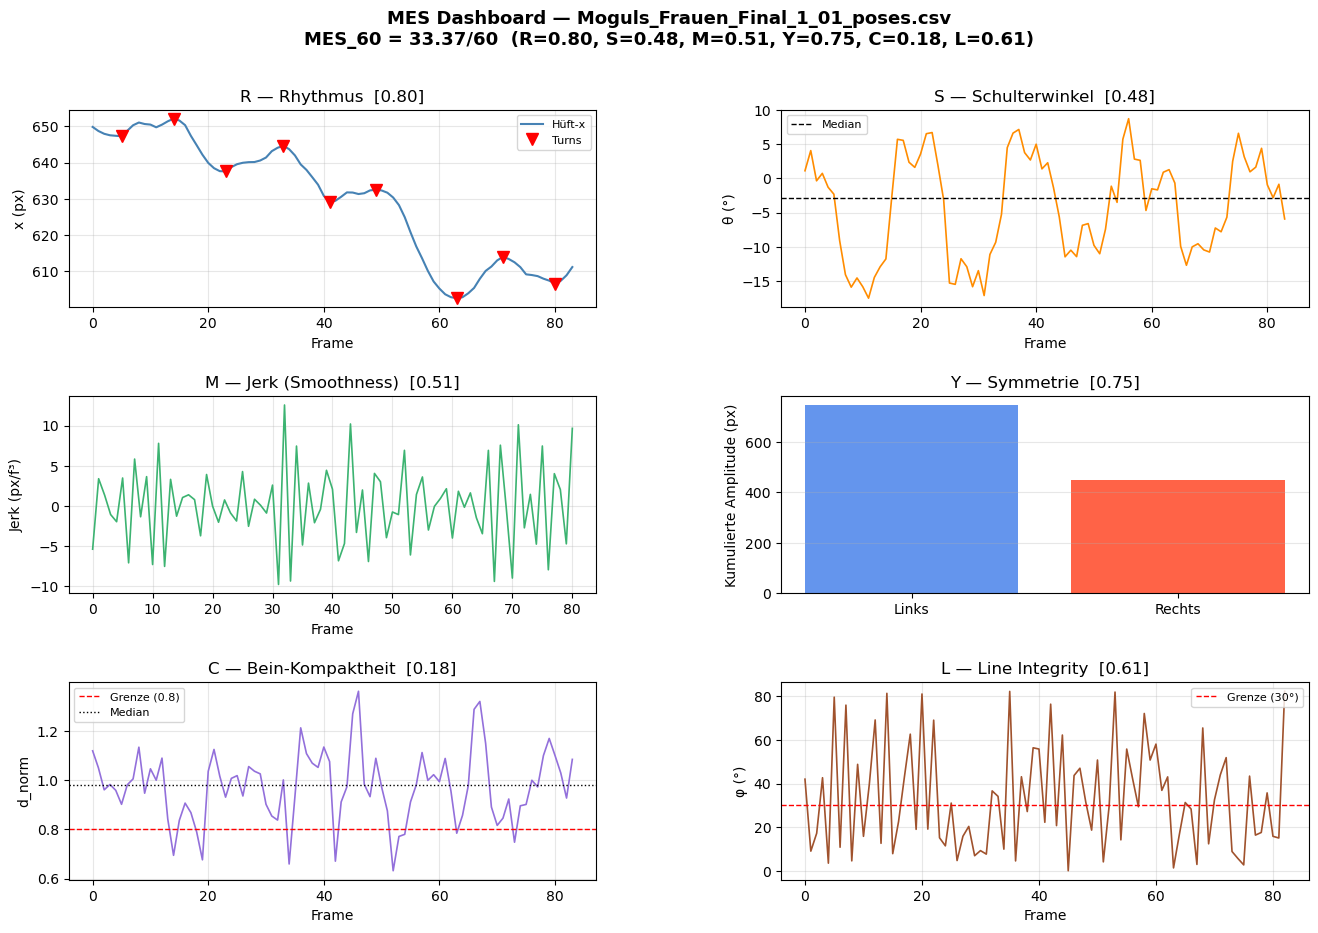

In [13]:
def plot_mes_dashboard(result: dict, figsize=(16, 10)):
    """
    Zeichnet ein 6-Panel-Dashboard für alle MES-Teilscores.
    """
    d = result['_details']
    fig = plt.figure(figsize=figsize)
    fig.suptitle(
        f"MES Dashboard — {result['file']}\n"
        f"MES_60 = {result['MES_60']:.2f}/60  "
        f"(R={result['R']:.2f}, S={result['S']:.2f}, M={result['M']:.2f}, "
        f"Y={result['Y']:.2f}, C={result['C']:.2f}, L={result['L']:.2f})",
        fontsize=13, fontweight='bold'
    )
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Panel 1: Rhythmus ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    hip = d['rhythmus'].get('hip_cx')
    peaks = d['rhythmus'].get('peaks', np.array([]))
    if hip is not None:
        ax1.plot(hip, color='steelblue', lw=1.5, label='Hüft-x')
        if len(peaks) > 0:
            ax1.plot(peaks, hip[peaks], 'rv', ms=8, label='Turns')
    ax1.set_title(f"R — Rhythmus  [{result['R']:.2f}]")
    ax1.set_xlabel('Frame'); ax1.set_ylabel('x (px)')
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    # ── Panel 2: Stabilität ──────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    theta = d['stabilitaet'].get('theta')
    if theta is not None:
        ax2.plot(theta, color='darkorange', lw=1.2)
        ax2.axhline(np.nanmedian(theta), color='k', ls='--', lw=1, label='Median')
    ax2.set_title(f"S — Schulterwinkel  [{result['S']:.2f}]")
    ax2.set_xlabel('Frame'); ax2.set_ylabel('θ (°)')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # ── Panel 3: Smoothness (Jerk) ───────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
    jerk = d['smoothness'].get('jerk')
    if jerk is not None:
        ax3.plot(jerk, color='mediumseagreen', lw=1.2)
    ax3.set_title(f"M — Jerk (Smoothness)  [{result['M']:.2f}]")
    ax3.set_xlabel('Frame'); ax3.set_ylabel('Jerk (px/f³)')
    ax3.grid(alpha=0.3)

    # ── Panel 4: Symmetrie ───────────────────────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
    L_amp = result['_details']['symmetrie'].get('L_amp', 0)
    R_amp = result['_details']['symmetrie'].get('R_amp', 0)
    ax4.bar(['Links', 'Rechts'], [L_amp, R_amp],
            color=['cornflowerblue', 'tomato'])
    ax4.set_title(f"Y — Symmetrie  [{result['Y']:.2f}]")
    ax4.set_ylabel('Kumulierte Amplitude (px)')
    ax4.grid(alpha=0.3, axis='y')

    # ── Panel 5: Bein-Kompaktheit ────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 0])
    d_norm = d['kompaktheit'].get('d_norm')
    if d_norm is not None:
        ax5.plot(d_norm, color='mediumpurple', lw=1.2)
        ax5.axhline(0.8, color='r', ls='--', lw=1, label='Grenze (0.8)')
        ax5.axhline(np.nanmedian(d_norm), color='k', ls=':', lw=1, label='Median')
    ax5.set_title(f"C — Bein-Kompaktheit  [{result['C']:.2f}]")
    ax5.set_xlabel('Frame'); ax5.set_ylabel('d_norm')
    ax5.legend(fontsize=8); ax5.grid(alpha=0.3)

    # ── Panel 6: Line Integrity ──────────────────────────────────────────
    ax6 = fig.add_subplot(gs[2, 1])
    phi = d['line_integrity'].get('phi')
    if phi is not None:
        ax6.plot(phi, color='sienna', lw=1.2)
        ax6.axhline(30, color='r', ls='--', lw=1, label='Grenze (30°)')
    ax6.set_title(f"L — Line Integrity  [{result['L']:.2f}]")
    ax6.set_xlabel('Frame'); ax6.set_ylabel('φ (°)')
    ax6.legend(fontsize=8); ax6.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()


plot_mes_dashboard(result)

## 7. Radar-Chart — Teilscores im Überblick

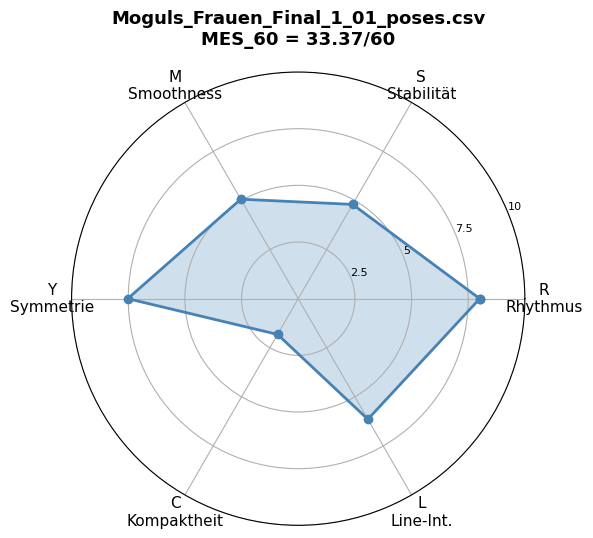

In [14]:
def plot_radar(result: dict):
    labels = ['R\nRhythmus', 'S\nStabilität', 'M\nSmoothness',
              'Y\nSymmetrie', 'C\nKompaktheit', 'L\nLine-Int.']
    values = [result['R'], result['S'], result['M'],
              result['Y'], result['C'], result['L']]

    N = len(labels)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    values_plot = values + [values[0]]  # schliessen
    angles_plot = angles + [angles[0]]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'polar': True})
    ax.plot(angles_plot, values_plot, 'o-', lw=2, color='steelblue')
    ax.fill(angles_plot, values_plot, alpha=0.25, color='steelblue')
    ax.set_thetagrids(np.degrees(angles), labels, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['2.5', '5', '7.5', '10'], fontsize=8)
    ax.set_title(
        f"{result['file']}\nMES_60 = {result['MES_60']:.2f}/60",
        fontsize=13, fontweight='bold', pad=20
    )
    ax.grid(True)
    plt.tight_layout()
    plt.show()


plot_radar(result)

## 8. Batch-Analyse — alle Videos

In [15]:
all_results = []

for csv_path in csv_files:
    try:
        res = compute_mes(csv_path, verbose=False)
        # Videolänge = Anzahl Frames in der CSV
        df_tmp = pd.read_csv(csv_path)
        res['n_frames'] = len(df_tmp)
        res['duration_s'] = round(len(df_tmp) / 25, 1)  # 25fps
        all_results.append(res)
    except Exception as e:
        print(f'  FEHLER bei {csv_path.name}: {e}')

# Als DataFrame
df_summary = pd.DataFrame([
    {k: v for k, v in r.items() if k != '_details'}
    for r in all_results
])

df_summary = df_summary.sort_values('MES_60', ascending=False).reset_index(drop=True)
print(f'\n{len(df_summary)} Videos analysiert.')
print(f'Videolänge: min={df_summary["n_frames"].min()}f, max={df_summary["n_frames"].max()}f, '
      f'median={df_summary["n_frames"].median():.0f}f '
      f'({df_summary["duration_s"].min()}s – {df_summary["duration_s"].max()}s bei 25fps)')
df_summary.round(3)



52 Videos analysiert.
Videolänge: min=63f, max=319f, median=104f (2.5s – 12.8s bei 25fps)


,file,R,S,M,Y,C,L,MES_60,n_frames,duration_s
0,Moguls_Frauen_Final_2_08_poses.csv,0.909,0.634,0.544,0.856,0.236,0.735,39.147,118,4.7
1,Moguls_Männer_Final_1 - 07_poses.csv,0.866,0.571,0.596,0.958,0.205,0.672,38.685,65,2.6
2,Moguls_Männer_Final_1 - 04_poses.csv,0.857,0.628,0.494,0.678,0.251,0.766,36.746,78,3.1
3,Moguls_Frauen_Final_2_09_poses.csv,0.856,0.677,0.502,0.889,0.089,0.651,36.629,84,3.4
4,Moguls_Frauen_Final_2_01_poses.csv,0.693,0.608,0.627,0.853,0.237,0.644,36.615,147,5.9
5,Moguls_Frauen_Final_1_12_poses.csv,0.877,0.584,0.468,0.940,0.188,0.568,36.250,75,3.0
6,Moguls_Frauen_Final_2_04_poses.csv,0.831,0.606,0.376,0.954,0.228,0.629,36.239,179,7.2
7,Moguls_Männer_Final_1 - 03_poses.csv,0.539,0.589,0.587,0.966,0.221,0.677,35.786,100,4.0
8,Moguls_Frauen_Final_1_20_poses.csv,0.847,0.541,0.393,0.975,0.234,0.577,35.673,79,3.2
9,Moguls_Männer_Final_1 - 02_poses.csv,0.686,0.575,0.521,0.895,0.246,0.636,35.592,100,4.0


## 9. Ranking & Verteilungsplot

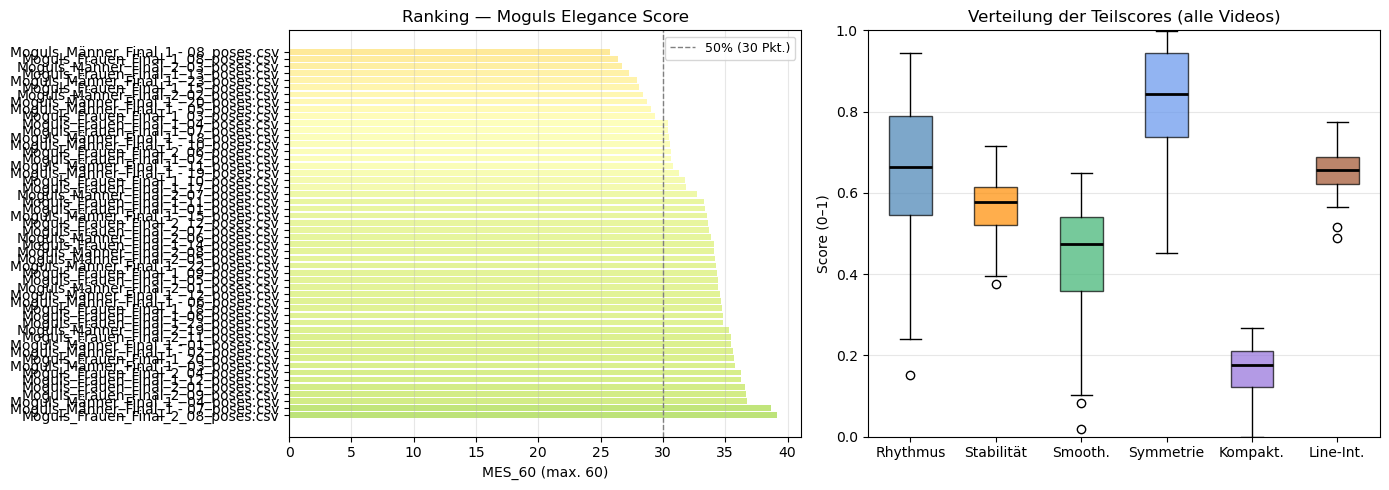

In [16]:
if not df_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── MES_60 Ranking (Balken) ───────────────────────────────────────────
    ax = axes[0]
    colors = plt.cm.RdYlGn(df_summary['MES_60'] / 60)
    ax.barh(df_summary['file'], df_summary['MES_60'], color=colors)
    ax.axvline(30, color='gray', ls='--', lw=1, label='50% (30 Pkt.)')
    ax.set_xlabel('MES_60 (max. 60)')
    ax.set_title('Ranking — Moguls Elegance Score')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='x')

    # ── Teilscores Boxplot ────────────────────────────────────────────────
    ax2 = axes[1]
    score_cols = ['R', 'S', 'M', 'Y', 'C', 'L']
    labels_full = ['Rhythmus', 'Stabilität', 'Smooth.', 'Symmetrie', 'Kompakt.', 'Line-Int.']
    data_bp = [df_summary[c].dropna().values for c in score_cols]
    bp = ax2.boxplot(data_bp, labels=labels_full, patch_artist=True,
                     medianprops={'color': 'black', 'lw': 2})
    colors_bp = ['steelblue','darkorange','mediumseagreen','cornflowerblue','mediumpurple','sienna']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Score (0–1)')
    ax2.set_title('Verteilung der Teilscores (alle Videos)')
    ax2.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

## 10. Ergebnisse exportieren

In [17]:
output_path = CSV_DIR / 'mes_scores.csv'
df_summary.to_csv(output_path, index=False)
print(f'Ergebnisse gespeichert: {output_path}')
df_summary

Ergebnisse gespeichert: runs/2026-03-02_220528_v8n-pose_conf20/data/mes_scores.csv


,file,R,S,M,Y,C,L,MES_60,n_frames,duration_s
0,Moguls_Frauen_Final_2_08_poses.csv,0.909278,0.634420,0.544059,0.855549,0.236387,0.735043,39.147358,118,4.7
1,Moguls_Männer_Final_1 - 07_poses.csv,0.866369,0.570895,0.596322,0.957893,0.205118,0.671875,38.684728,65,2.6
2,Moguls_Männer_Final_1 - 04_poses.csv,0.857058,0.628086,0.494169,0.677941,0.251083,0.766234,36.745704,78,3.1
3,Moguls_Frauen_Final_2_09_poses.csv,0.855662,0.677392,0.501644,0.888851,0.088750,0.650602,36.629027,84,3.4
4,Moguls_Frauen_Final_2_01_poses.csv,0.693100,0.607580,0.627384,0.853052,0.236575,0.643836,36.615264,147,5.9
5,Moguls_Frauen_Final_1_12_poses.csv,0.877162,0.584412,0.467681,0.940191,0.187976,0.567568,36.249891,75,3.0
6,Moguls_Frauen_Final_2_04_poses.csv,0.830895,0.606098,0.375983,0.953656,0.228061,0.629213,36.239051,179,7.2
7,Moguls_Männer_Final_1 - 03_poses.csv,0.538539,0.588995,0.587216,0.965764,0.221280,0.676768,35.785614,100,4.0
8,Moguls_Frauen_Final_1_20_poses.csv,0.847003,0.540805,0.393410,0.975217,0.233912,0.576923,35.672690,79,3.2
9,Moguls_Männer_Final_1 - 02_poses.csv,0.686091,0.575460,0.520707,0.894932,0.245684,0.636364,35.592377,100,4.0


---
## 11. Vergleich MES vs. Jury-Wertung

Matching-Logik: `Moguls_{Frauen|Männer}_Final_{1|2}_{Bib:02d}_poses.csv`  
Nur Videos die **sowohl** in den MES-Resultaten als auch in den Ratings vorhanden sind werden verglichen.  

> **Interpretation:** Wir erwarten für Phase 1 keine hohe absolute Übereinstimmung,  
> sondern prüfen ob die **Rangkorrelation** (Spearman) positiv ist —  
> d.h. ob Videos die die Jury hoch wertet auch tendenziell höhere MES-Scores haben.

In [18]:
# ── Ratings laden ─────────────────────────────────────────────────────────
RATINGS_PATH = Path('Mogul_Ratings.csv')  # Pfad zur Ratings-CSV anpassen

df_ratings = pd.read_csv(RATINGS_PATH)

# Erwarteten Dateinamen für jede Jury-Zeile konstruieren
def build_fname(row):
    gender = 'Frauen' if row['Gender'] == 'W' else 'Männer'
    comp   = row['Competition'].replace(' ', '_')
    bib    = str(int(row['Bib'])).zfill(2)
    
    if row['Gender'] == 'M' and row['Competition'] == 'Final 1':
        return f'Moguls_{gender}_{comp} - {bib}_poses.csv'  # Leerzeichen-Bindestrich-Leerzeichen
    else:
        return f'Moguls_{gender}_{comp}_{bib}_poses.csv'

df_ratings['fname'] = df_ratings.apply(build_fname, axis=1)

print(f'Ratings geladen: {len(df_ratings)} Einträge')
print(df_ratings[['fname', 'Gender', 'Competition', 'Name', 'Total']].to_string(index=False))

Ratings geladen: 32 Einträge
                               fname Gender Competition               Name  Total
  Moguls_Frauen_Final_1_01_poses.csv      W     Final 1      Antony Jakara   48.1
  Moguls_Frauen_Final_1_07_poses.csv      W     Final 1        Kauf Jaelin   47.0
  Moguls_Frauen_Final_1_06_poses.csv      W     Final 1    Tomitaka Hinako   46.8
  Moguls_Frauen_Final_1_04_poses.csv      W     Final 1   Lemley Elizabeth   45.2
  Moguls_Frauen_Final_1_12_poses.csv      W     Final 1   Wilson Charlotte   45.8
  Moguls_Frauen_Final_1_09_poses.csv      W     Final 1 Schwinghammer Maia   44.4
  Moguls_Frauen_Final_1_08_poses.csv      W     Final 1     Carroll Avital   45.2
  Moguls_Frauen_Final_1_11_poses.csv      W     Final 1   Laffonte Perrine   46.1
  Moguls_Frauen_Final_2_04_poses.csv      W     Final 2   Lemley Elizabeth   47.3
  Moguls_Frauen_Final_2_07_poses.csv      W     Final 2        Kauf Jaelin   47.3
  Moguls_Frauen_Final_2_11_poses.csv      W     Final 2   Laffonte Pe

In [19]:
# ── MES-Resultate mit Ratings mergen ──────────────────────────────────────
# df_summary muss aus Sektion 8 vorhanden sein

df_compare = df_summary.merge(
    df_ratings[['fname', 'Name', 'Gender', 'Competition', 'Rank', 'Total']],
    left_on='file', right_on='fname',
    how='inner'
)

print(f'Gematchte Videos: {len(df_compare)} von {len(df_summary)} MES / {len(df_ratings)} Ratings')
if len(df_compare) == 0:
    print('\n⚠️  Kein Match — Dateinamen prüfen!')
    print('Vorhandene MES-Files:', df_summary['file'].tolist()[:5])
    print('Erwartete Ratings-Files:', df_ratings['fname'].tolist()[:5])
else:
    print(df_compare[['Name', 'Gender', 'Competition', 'MES_60', 'Total', 'Rank']]
          .sort_values('Total', ascending=False).to_string(index=False))

Gematchte Videos: 32 von 52 MES / 32 Ratings
              Name Gender Competition    MES_60  Total  Rank
      Woods Cooper      M     Final 2 35.288879   48.4     1
    Harvey Jackson      M     Final 1 25.725510   48.4     8
   Horishima Ikuma      M     Final 2 34.397747   48.3     3
   Horishima Ikuma      M     Final 1 35.492803   48.3     5
      Woods Cooper      M     Final 1 31.311129   48.2     1
     Antony Jakara      W     Final 1 33.366303   48.1     1
  Kingsbury Mikael      M     Final 1 34.689741   48.0     2
       Graham Matt      M     Final 1 35.592377   48.0     3
  Kingsbury Mikael      M     Final 2 33.817381   47.7     2
  Lemley Elizabeth      W     Final 2 36.239051   47.3     1
       Kauf Jaelin      W     Final 2 33.733450   47.3     2
       Kauf Jaelin      W     Final 1 30.431945   47.0     2
       Viel Julien      M     Final 1 29.028969   46.9     7
   Tomitaka Hinako      W     Final 1 34.791633   46.8     3
   Wallberg Walter      M     Final 1 38

In [20]:
# ── Korrelationsanalyse ────────────────────────────────────────────────────
from scipy.stats import spearmanr, pearsonr

if len(df_compare) >= 3:
    # Gesamt (Männer + Frauen, alle Finals gemischt — nur als Orientierung)
    spear_r, spear_p = spearmanr(df_compare['MES_60'], df_compare['Total'])
    pears_r, pears_p = pearsonr(df_compare['MES_60'], df_compare['Total'])

    print('=== Korrelation MES_60 vs. Jury Turn-Score ===')
    print()
    print('  Gesamt (alle Gruppen gemischt — nur Orientierung):')
    print(f'    Spearman ρ = {spear_r:+.3f}  (p = {spear_p:.3f})')
    print(f'    Pearson  r = {pears_r:+.3f}  (p = {pears_p:.3f})')
    print()

    # Gruppenweise (korrekte Vergleichsebene — wie Jury-Rangierung)
    print('  Gruppenweise Spearman ρ (innerhalb Gender × Competition):')
    print(f'  {"Gruppe":<25}  ρ        p       n')
    print('  ' + '-'*45)
    for group, gdf in df_compare.groupby(['Gender', 'Competition']):
        label = f"{group[0]} — {group[1]}"
        if len(gdf) >= 3:
            r, p = spearmanr(gdf['MES_60'], gdf['Total'])
            print(f'  {label:<25}  {r:+.3f}    {p:.3f}    {len(gdf)}')
        else:
            print(f'  {label:<25}  (zu wenige Datenpunkte: n={len(gdf)})')
    print()
    print('  Interpretation Spearman ρ:')
    print('   > +0.6  → starke Rangkorrelation (gut für Phase 1)')
    print('   > +0.3  → schwache aber positive Korrelation (akzeptabel)')
    print('     ~0    → kein Zusammenhang')
    print('   < 0     → inverse Korrelation (Logik-Problem)')

    # Offset
    offset = df_compare['Total'].mean() - df_compare['MES_60'].mean()
    print(f'\n  Mittlerer Offset MES→Jury: +{offset:.1f} Punkte')
    print(f'  (MES liegt im Schnitt {offset:.1f} Pkt. unter der Jury-Wertung)')

else:
    print(f'Zu wenige gematchte Videos für Korrelation ({len(df_compare)} < 3)')

=== Korrelation MES_60 vs. Jury Turn-Score ===

  Gesamt (alle Gruppen gemischt — nur Orientierung):
    Spearman ρ = -0.042  (p = 0.819)
    Pearson  r = -0.128  (p = 0.486)

  Gruppenweise Spearman ρ (innerhalb Gender × Competition):
  Gruppe                     ρ        p       n
  ---------------------------------------------
  M — Final 1                -0.647    0.083    8
  M — Final 2                +0.643    0.086    8
  W — Final 1                +0.156    0.713    8
  W — Final 2                -0.407    0.317    8

  Interpretation Spearman ρ:
   > +0.6  → starke Rangkorrelation (gut für Phase 1)
   > +0.3  → schwache aber positive Korrelation (akzeptabel)
     ~0    → kein Zusammenhang
   < 0     → inverse Korrelation (Logik-Problem)

  Mittlerer Offset MES→Jury: +12.4 Punkte
  (MES liegt im Schnitt 12.4 Pkt. unter der Jury-Wertung)


In [21]:
# Debug: welche Gruppen sind im df_compare vorhanden?
print("Gruppen in df_compare:")
print(df_compare.groupby(['Gender', 'Competition'])['Name'].apply(list))

print("\nFehlen in Ratings aber nicht in MES:")
männer_f1_ratings = df_ratings[(df_ratings['Gender'] == 'M') & 
                                (df_ratings['Competition'] == 'Final 1')]
print("Erwartete Filenames:")
print(männer_f1_ratings['fname'].tolist())

print("\nVorhandene MES-Files (Männer):")
print([f for f in df_summary['file'].tolist() if 'Männer' in f])

Gruppen in df_compare:
Gender  Competition
M       Final 1        [Wallberg Walter, Page Nick, Graham Matt, Hori...
        Final 2        [Woods Cooper, Horishima Ikuma, Viel Julien, H...
W       Final 1        [Wilson Charlotte, Tomitaka Hinako, Schwingham...
        Final 2        [Carroll Avital, Schwinghammer Maia, Antony Ja...
Name: Name, dtype: object

Fehlen in Ratings aber nicht in MES:
Erwartete Filenames:
['Moguls_Männer_Final_1 - 19_poses.csv', 'Moguls_Männer_Final_1 - 06_poses.csv', 'Moguls_Männer_Final_1 - 02_poses.csv', 'Moguls_Männer_Final_1 - 07_poses.csv', 'Moguls_Männer_Final_1 - 01_poses.csv', 'Moguls_Männer_Final_1 - 03_poses.csv', 'Moguls_Männer_Final_1 - 05_poses.csv', 'Moguls_Männer_Final_1 - 08_poses.csv']

Vorhandene MES-Files (Männer):
['Moguls_Männer_Final_1 - 07_poses.csv', 'Moguls_Männer_Final_1 - 04_poses.csv', 'Moguls_Männer_Final_1 - 03_poses.csv', 'Moguls_Männer_Final_1 - 02_poses.csv', 'Moguls_Männer_Final_1 - 01_poses.csv', 'Moguls_Männer_Final_2_19_

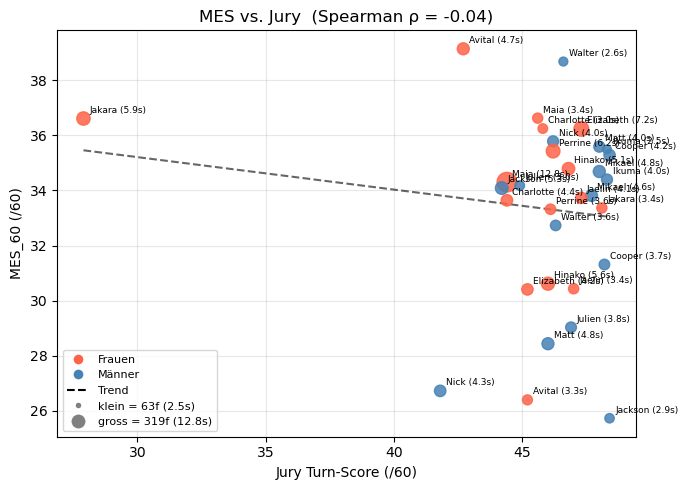

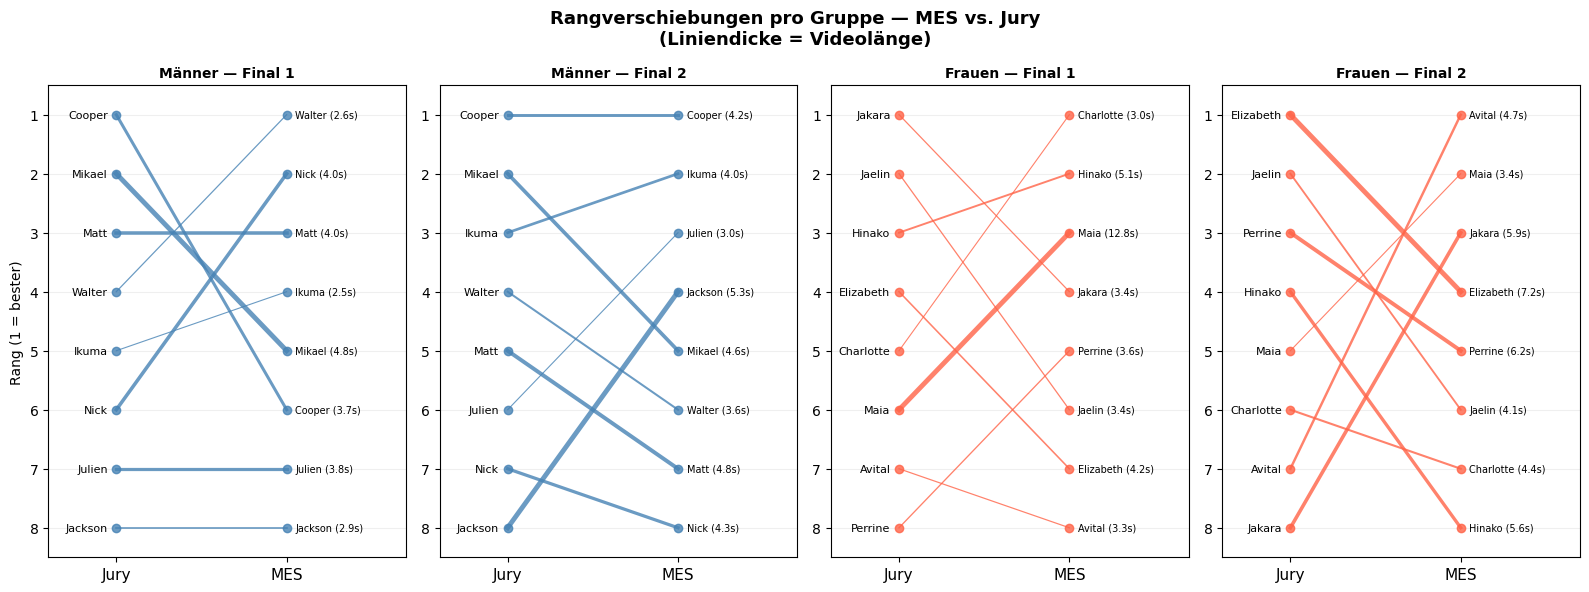

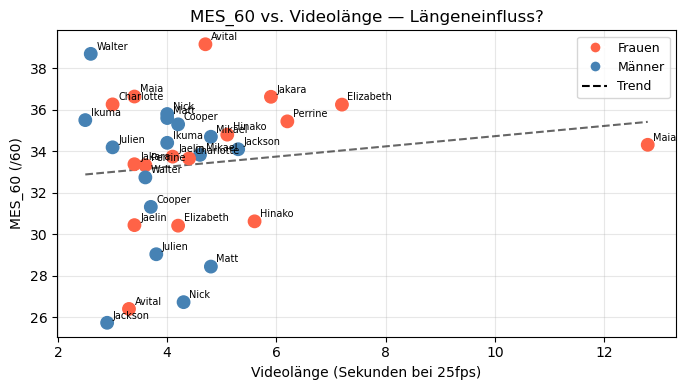

In [22]:
# ── Vergleichsplot ─────────────────────────────────────────────────────────
if len(df_compare) >= 3:
    df_compare = df_compare.copy()
    df_compare['MES_Rank'] = df_compare.groupby(['Gender', 'Competition'])['MES_60']\
                                        .rank(ascending=False).astype(int)

    groups = list(df_compare.groupby(['Gender', 'Competition']))
    n_groups = len(groups)

    # Punktgrösse proportional zur Videolänge (normiert auf 40–200)
    f_min, f_max = df_compare['n_frames'].min(), df_compare['n_frames'].max()
    if f_max > f_min:
        df_compare['bubble'] = 40 + 160 * (df_compare['n_frames'] - f_min) / (f_max - f_min)
    else:
        df_compare['bubble'] = 80

    # ── Plot 1: Scatter MES vs. Jury — Punktgrösse = Videolänge ──────────
    fig1, ax = plt.subplots(figsize=(7, 5))
    colors_g = df_compare['Gender'].map({'W': 'tomato', 'M': 'steelblue'})
    sc = ax.scatter(df_compare['Total'], df_compare['MES_60'],
                    c=colors_g, s=df_compare['bubble'], zorder=3, alpha=0.85)

    m, b = np.polyfit(df_compare['Total'], df_compare['MES_60'], 1)
    x_line = np.linspace(df_compare['Total'].min(), df_compare['Total'].max(), 50)
    ax.plot(x_line, m * x_line + b, 'k--', lw=1.5, alpha=0.6)

    for _, row in df_compare.iterrows():
        ax.annotate(f"{row['Name'].split()[-1]} ({row['duration_s']}s)",
                    (row['Total'], row['MES_60']),
                    fontsize=6.5, xytext=(4, 4), textcoords='offset points')

    ax.set_xlabel('Jury Turn-Score (/60)')
    ax.set_ylabel('MES_60 (/60)')
    ax.set_title(f'MES vs. Jury  (Spearman ρ = {spear_r:+.2f})')
    ax.grid(alpha=0.3)

    from matplotlib.lines import Line2D
    # Legende: Gender + Grössenreferenz
    handles = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato', ms=8, label='Frauen'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', ms=8, label='Männer'),
        Line2D([0],[0], color='k', ls='--', lw=1.5, label='Trend'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               ms=5, label=f'klein = {f_min}f ({f_min/25:.1f}s)'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               ms=11, label=f'gross = {f_max}f ({f_max/25:.1f}s)'),
    ]
    ax.legend(handles=handles, fontsize=8)
    plt.tight_layout()
    plt.show()

    # ── Plot 2: Rangverschiebungen — Liniendicke = Videolänge ─────────────
    fig2, axes2 = plt.subplots(1, n_groups, figsize=(4 * n_groups, 6), sharey=False)
    if n_groups == 1:
        axes2 = [axes2]

    # Linienbreite normiert auf 0.8–3.5
    lw_min, lw_max = 0.8, 3.5

    for ax2, ((gender, comp), gdf) in zip(axes2, groups):
        color = 'tomato' if gender == 'W' else 'steelblue'
        label = f"{'Frauen' if gender == 'W' else 'Männer'} — {comp}"

        g_fmin = gdf['n_frames'].min()
        g_fmax = gdf['n_frames'].max()

        for _, row in gdf.iterrows():
            # Linienbreite proportional zur Videolänge innerhalb der Gruppe
            if g_fmax > g_fmin:
                lw = lw_min + (lw_max - lw_min) * (row['n_frames'] - g_fmin) / (g_fmax - g_fmin)
            else:
                lw = 2.0
            ax2.plot([0, 1], [row['Rank'], row['MES_Rank']],
                     'o-', color=color, lw=lw, ms=6, alpha=0.8)
            ax2.annotate(f"{row['Name'].split()[-1]} ({row['duration_s']}s)",
                         (1.05, row['MES_Rank']), fontsize=7, va='center')
            ax2.annotate(row['Name'].split()[-1], (-0.05, row['Rank']),
                         fontsize=8, va='center', ha='right')

        ax2.set_xlim(-0.4, 1.7)
        ax2.set_xticks([0, 1])
        ax2.set_xticklabels(['Jury', 'MES'], fontsize=11)
        ax2.set_yticks(range(1, 9))
        ax2.set_ylim(0.5, 8.5)
        ax2.invert_yaxis()
        ax2.set_title(label, fontsize=10, fontweight='bold')
        ax2.grid(alpha=0.2, axis='y')
        if ax2 == axes2[0]:
            ax2.set_ylabel('Rang (1 = bester)')

    fig2.suptitle('Rangverschiebungen pro Gruppe — MES vs. Jury\n'
                  '(Liniendicke = Videolänge)',
                  fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ── Plot 3: MES_60 vs. Videolänge — zeigt ob längere Videos besser/schlechter abschneiden
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    colors_g2 = df_compare['Gender'].map({'W': 'tomato', 'M': 'steelblue'})
    ax3.scatter(df_compare['duration_s'], df_compare['MES_60'], c=colors_g2, s=80, zorder=3)

    if df_compare['duration_s'].nunique() > 1:
        m2, b2 = np.polyfit(df_compare['duration_s'], df_compare['MES_60'], 1)
        x2 = np.linspace(df_compare['duration_s'].min(), df_compare['duration_s'].max(), 50)
        ax3.plot(x2, m2 * x2 + b2, 'k--', lw=1.5, alpha=0.6, label='Trend')

    for _, row in df_compare.iterrows():
        ax3.annotate(row['Name'].split()[-1], (row['duration_s'], row['MES_60']),
                     fontsize=7, xytext=(4, 3), textcoords='offset points')

    ax3.set_xlabel('Videolänge (Sekunden bei 25fps)')
    ax3.set_ylabel('MES_60 (/60)')
    ax3.set_title('MES_60 vs. Videolänge — Längeneinfluss?')
    ax3.grid(alpha=0.3)
    from matplotlib.lines import Line2D as L2D
    ax3.legend(handles=[
        L2D([0],[0], marker='o', color='w', markerfacecolor='tomato', ms=8, label='Frauen'),
        L2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', ms=8, label='Männer'),
        L2D([0],[0], color='k', ls='--', lw=1.5, label='Trend'),
    ], fontsize=9)
    plt.tight_layout()
    plt.show()


In [23]:
# ── Teilscores vs. Jury: welche Komponente korreliert am stärksten? ────────
if len(df_compare) >= 3:
    print('=== Korrelation Einzelkomponenten vs. Jury Turn-Score ===')
    print(f'  {"Komponente":<25}  Spearman ρ   p-Wert')
    print('  ' + '-'*45)
    for col, label in [('R','R — Rhythmus'), ('S','S — Stabilität'), 
                        ('M','M — Smoothness'), ('Y','Y — Symmetrie'),
                        ('C','C — Kompaktheit'), ('L','L — Line Integrity')]:
        r, p = spearmanr(df_compare[col], df_compare['Total'])
        sig = '✓' if p < 0.05 else ' '
        print(f'  {label:<25}  {r:+.3f}       {p:.3f}  {sig}')
    print()
    print('  ✓ = statistisch signifikant (p < 0.05)')
    print('  Hinweis: Bei n < 10 ist p < 0.05 sehr schwer zu erreichen.')

=== Korrelation Einzelkomponenten vs. Jury Turn-Score ===
  Komponente                 Spearman ρ   p-Wert
  ---------------------------------------------
  R — Rhythmus               -0.127       0.488   
  S — Stabilität             +0.082       0.657   
  M — Smoothness             +0.120       0.514   
  Y — Symmetrie              -0.346       0.052   
  C — Kompaktheit            +0.092       0.618   
  L — Line Integrity         -0.048       0.793   

  ✓ = statistisch signifikant (p < 0.05)
  Hinweis: Bei n < 10 ist p < 0.05 sehr schwer zu erreichen.


---
## Kalibrierungsreferenz — aktuelle Parameterwerte

Alle Werte wurden auf Basis von `Moguls_Frauen_Final_1_01` (84 Frames, YOLOv8 nano) kalibriert.
**Bei Modellwechsel oder anderem Kamerasetup neu validieren.**

| Parameter | Funktion | Aktueller Wert | Gemessener Rohwert | Formel |
|-----------|----------|---------------|-------------------|--------|
| `sigma_max` | Schulterneigung | **14°** | σ = 7.28° | 2 × σ |
| `jerk_max` | Smoothness-Grenze | **10.0 px/f³** | Jerk RMS = 4.93 | 2 × RMS |
| `d_max` | Beinabstand-Grenze | **1.2** | d_norm median = 0.98 | ~1.2× median |
| `phi_threshold` | Falllinie-Toleranz | **40°** | phi median = 29.8° | median + 10° |
| `distance` (Peaks) | Artefakt-Filter | **8 Frames** | kürzeste echte Turns: ~8–9f | physikalisch |
| `conf_threshold` | Keypoint-Konfidenz | **0.3** | alle KP > 0.9 in diesem Video | Phase-1-Wert |

> Siehe Sektion 11 und 12 für Hinweise wann und wie Parameter angepasst werden sollen.


---
## 12. Hinweise zur YOLO-Pipeline (Phase 1 → Phase 2)

### Aktueller Stand (Phase 1)
Die Pose-Daten wurden mit **YOLOv8 nano** und niedrigen Konfidenzwerten extrahiert.  
Das ist bewusst so — in Phase 1 geht es darum, die Pipeline zum Laufen zu bringen und  
ein erstes Gefühl für die Daten zu entwickeln. Die MES-Scores sind deshalb noch **nicht  
interpretierbar als absolute Qualitätswerte**.

### Was sich mit besserem YOLO-Modell verbessert

| Problem (Phase 1) | Ursache | Lösung (Phase 2) |
|---|---|---|
| Artefakt-Peaks im Rhythmus-Score | nano-Modell "zittert" bei Keypoints | `yolov8m-pose` oder `yolov8l-pose` |
| Hoher Jerk trotz flüssiger Bewegung | Rauschen in Keypoint-Koordinaten | grösseres Modell, höhere `conf` |
| Mehrere Track-IDs pro Skier | ByteTracker-Parameter nicht optimiert | `track_thresh`, `match_thresh` tunen |
| Knieabstand wirkt gross | Perspektivverzerrung + Rauschen | Skelett-Normierung auf Körperhöhe |

### Wann auf ein grösseres Modell wechseln?
Erst dann, wenn:
1. Die Pipeline stabil läuft (keine Abstürze, saubere CSVs)
2. Das Tracking-Problem (mehrere IDs) gelöst ist
3. Die MES-Komponenten konzeptionell validiert sind (stimmt die Logik?)

> **Faustregel:** Modellwechsel erst *nach* konzeptioneller Validierung —  
> sonst weiss man nicht ob bessere Scores vom Modell oder von der Logik kommen.


---
## 13. Wann und wie Parameter anpassen?

### Grundprinzip: Parameter erst anpassen wenn man weiss warum

Parameter-Tuning ohne Verständnis der Ursache führt dazu, dass man  
Scores "schönrechnet" statt wirklich besser misst. Folge deshalb dieser Reihenfolge:

```
1. Score sieht komisch aus
2. Diagnose-Dashboard anschauen (Sektion 6)
3. Ursache identifizieren (Modell-Rauschen? Kamerawinkel? Logik-Fehler?)
4. Erst dann anpassen
```

### Normierungsparameter (sigma_max, jerk_max, d_max, phi_threshold)

Diese Parameter bestimmen **was als «gut» gilt** — sie sind keine technischen Schrauben,  
sondern sportliche Aussagen. Deshalb:

| Parameter | Bedeutung der Aussage | Anpassen wenn... | NICHT anpassen wenn... |
|---|---|---|---|
| `sigma_max` | «Ab X° Schulterneigung ist es schlecht» | Kamerawinkel ändert sich stark | Score zu tief, Logik aber korrekt |
| `jerk_max` | «Ab X px/f³ Jerk ist es ruckartig» | Modell gewechselt (anderes Rauschen) | Scores generell tief |
| `d_max` | «Ab X × Hüftbreite sind Beine zu weit» | Andere Videogrösse / Auflösung | Man findet Scores unplausibel |
| `phi_threshold` | «Ab X° ist man nicht mehr in der Falllinie» | Kamerawinkel bekannt und anders als 90° | L-Scores generell tief |

### Peak-Detection Parameter (distance in Rhythmus)

`distance` in `find_peaks` ist **kein** sportlicher Parameter, sondern ein technischer Filter:  
Er sagt «zwei echte Turns können nicht weniger als X Frames auseinanderliegen».  
Aktuell: 8 Frames = 0.32s bei 25fps — das ist eine physikalische Untergrenze, kein Qualitätskriterium.  
Nur anpassen wenn die Framerate der Videos sich ändert.

### Wann sind die Scores vertrauenswürdig?

Die Scores sind **relativ vertrauenswürdig** (= für Vergleiche verwendbar), sobald:
- Alle Videos mit demselben Modell und denselben Einstellungen verarbeitet wurden
- Das Tracking stabil ist (1 ID pro Skier pro Video)
- Das Diagnose-Dashboard keine offensichtlichen Artefakte mehr zeigt

Sie sind **absolut vertrauenswürdig** (= Vergleich mit FIS-Wertung möglich) erst nach:  
- Validierung gegen echte Jury-Scores (Korrelationsanalyse)
- Mindestens 1 vollständiger Wettkampf-Datensatz

> **Für Phase 1 gilt:** Die Scores zeigen Tendenzen, keine Wahrheiten.  
> Nutzt sie um die Pipeline zu testen und Extremfälle zu finden — nicht um Skifahrer zu beurteilen.
